# B24 — Shor's Order Finding (N = 15, 21)

**Track B — the SDK.** B23 estimated the phase of a `PhaseGate`, an operator
whose eigenvalue you already knew because you typed it in. This notebook points
the same machine at an operator whose eigenvalues encode something nobody typed
in: the multiplicative order of $a$ modulo $N$. That number factors $N$.

---

## The one-sentence version

Shor's algorithm is phase estimation on the map $|x\rangle \mapsto |ax \bmod N\rangle$,
and it works because that map's eigenvalues are $e^{2\pi i s/r}$ where $r$ is the
order — so reading a phase off the counting register and running continued
fractions on it hands you $r$, and $r$ hands you a factor.

## The one-sentence caveat, which most tutorials omit

The oracle in this notebook — and in essentially every runnable Shor demo, this
one included — is a **lookup table**: we write down the entire $2^n \times 2^n$
permutation matrix for $x \mapsto ax \bmod N$ and hand it to the transpiler.
That is exponentially large in the bit-length of $N$. It reproduces the
interference exactly and reproduces the speedup **not at all**. Part 7 draws the
gap. If a demo does not say this, it is selling you something.

## Why factoring is really order finding

Pick $a$ coprime to $N$. Let $r$ be its **order**: the smallest $r \ge 1$ with
$a^r \equiv 1 \pmod N$. If $r$ happens to be even, then

$$\left(a^{r/2}\right)^2 - 1 \equiv 0 \pmod N
\quad\Longrightarrow\quad
\left(a^{r/2}-1\right)\left(a^{r/2}+1\right) \equiv 0 \pmod N,$$

so $N$ divides that product while — provided $a^{r/2} \not\equiv -1$ — dividing
neither factor. Then $\gcd(a^{r/2} \pm 1,\, N)$ is a **non-trivial factor of
$N$**, computable with Euclid in microseconds.

Every step of that is classical and cheap. The one hard part is $r$, and that is
the only part the quantum computer does.

## The two ways this fails, and they are not rare

The derivation needed $r$ even **and** $a^{r/2} \not\equiv -1 \pmod N$. Both can
fail. For $N = 21$ they fail for five of the eleven usable bases — the classical
wrapper succeeds only $6/11 \approx 55\%$ of the time before the quantum part
has done anything wrong. Part 1 draws every base and every outcome; no averaging
over "a random $a$", the actual table.

## What we build here

| part | thing |
|---|---|
| 1 | the classical reduction, every base, both $N$ — the honest hit rate |
| 2 | the oracle as a permutation, and its cycle structure |
| 3 | its eigenvectors, and why $\|1\rangle$ is the right input |
| 4 | the circuit, and its output against a closed-form Dirichlet sum |
| 5 | real `SamplerV2` shots, with binomial error bars |
| 6 | continued fractions: which measurements actually yield $r$ |
| 7 | success rate vs counting qubits, and the $\varphi(r)/r$ ceiling |
| 8 | the RSA-2048 wall, and why our oracle is not on the road to it |

In [1]:
from qviz import backends, grid, style

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from fractions import Fraction
from math import gcd
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit.quantum_info import Operator, Statevector

style.use()

SEED = backends.seed_for("B24")
rng = np.random.default_rng(SEED)

print("qiskit", qiskit.__version__, " seed", SEED)

qiskit 2.5.1  seed 20260828


---

## Part 1 — the classical half, with no averaging

Order finding is the only quantum step. Everything around it is arithmetic, so
we can compute the *entire* outcome table exactly and look at it, rather than
quoting the textbook's "succeeds with probability at least $1/2$".

For each $a$ coprime to $N$ there are exactly three outcomes:

- **$r$ is odd** — $a^{r/2}$ is not an integer, the identity does not apply, and
  this base is dead. Try another.
- **$r$ is even but $a^{r/2} \equiv -1 \pmod N$** — then $a^{r/2}+1 \equiv 0$, so
  $\gcd(a^{r/2}+1, N) = N$ and $\gcd(a^{r/2}-1, N) = 1$. Both gcds are trivial.
  Dead as well.
- **otherwise** — a factor falls out.

Note what is *not* in that list: "the quantum part gave a wrong answer". These
failures happen before the quantum computer is switched on.

In [2]:
def order(a, N):
    """Multiplicative order of a mod N, by brute force. N is 15 or 21 here."""
    if gcd(a, N) != 1:
        raise ValueError(f"a={a} is not coprime to N={N}")
    r, x = 1, a % N
    while x != 1:
        x = (x * a) % N
        r += 1
    return r


def classical_outcome(a, N):
    """(r, verdict, factors) for base a -- the whole non-quantum algorithm."""
    r = order(a, N)
    if r % 2:
        return r, "r odd", None
    h = pow(a, r // 2, N)
    if h == N - 1:
        return r, "a^(r/2) = -1", None
    fs = tuple(sorted({gcd(h - 1, N), gcd(h + 1, N)} - {1, N}))
    return r, (f"factors {fs}", "trivial gcd")[not fs], fs or None


def bases(N):
    return [a for a in range(2, N) if gcd(a, N) == 1]


TABLE = {}
for N in (15, 21):
    rows = [(a, *classical_outcome(a, N)) for a in bases(N)]
    TABLE[N] = rows
    hits = sum(1 for _, _, _, f in rows if f)
    print(f"N = {N}   bases coprime to N: {len(rows)}")
    for a, r, why, f in rows:
        print(f"    a = {a:>2}   r = {r}   a^(r/2) mod N = "
              f"{pow(a, r // 2, N) if r % 2 == 0 else '-':>3}   {why}")
    print(f"    -> a factor falls out for {hits}/{len(rows)} bases "
          f"= {hits / len(rows):.3f}\n")

N = 15   bases coprime to N: 7
    a =  2   r = 4   a^(r/2) mod N =   4   factors (3, 5)
    a =  4   r = 2   a^(r/2) mod N =   4   factors (3, 5)
    a =  7   r = 4   a^(r/2) mod N =   4   factors (3, 5)
    a =  8   r = 4   a^(r/2) mod N =   4   factors (3, 5)
    a = 11   r = 2   a^(r/2) mod N =  11   factors (3, 5)
    a = 13   r = 4   a^(r/2) mod N =   4   factors (3, 5)
    a = 14   r = 2   a^(r/2) mod N =  14   a^(r/2) = -1
    -> a factor falls out for 6/7 bases = 0.857

N = 21   bases coprime to N: 11
    a =  2   r = 6   a^(r/2) mod N =   8   factors (3, 7)
    a =  4   r = 3   a^(r/2) mod N =   -   r odd
    a =  5   r = 6   a^(r/2) mod N =  20   a^(r/2) = -1
    a =  8   r = 2   a^(r/2) mod N =   8   factors (3, 7)
    a = 10   r = 6   a^(r/2) mod N =  13   factors (3, 7)
    a = 11   r = 6   a^(r/2) mod N =   8   factors (3, 7)
    a = 13   r = 2   a^(r/2) mod N =  13   factors (3, 7)
    a = 16   r = 3   a^(r/2) mod N =   -   r odd
    a = 17   r = 6   a^(r/2) mod N =  20

### Figure 1 — every base, both $N$, colour-coded by fate

Left two panels: one dot per base, height is the order $r$. Colour is the
verdict — blue for "a factor falls out", yellow for "$r$ odd", red for
"$a^{r/2} \equiv -1$". The dashed line at $r = 1$ is where a base would be
useless by definition; nothing sits there because $a=1$ is excluded.

The shape to notice is that $N = 15$ is a **bad example** and $N = 21$ is a
representative one. Fifteen is the number every tutorial uses, and six of its
seven bases work; it is small enough that the algorithm looks reliable. Twenty-one
is the smallest $N$ where all three verdicts occur, and its hit rate is barely
half.

Right panel: those hit rates as bars, against the textbook guarantee
($\ge 1/2$ for $N$ with at least two distinct odd prime factors, which both of
these are). The guarantee holds — but "holds" and "comfortable" are different
claims, and $N=15$ flatters the algorithm by a wide margin.

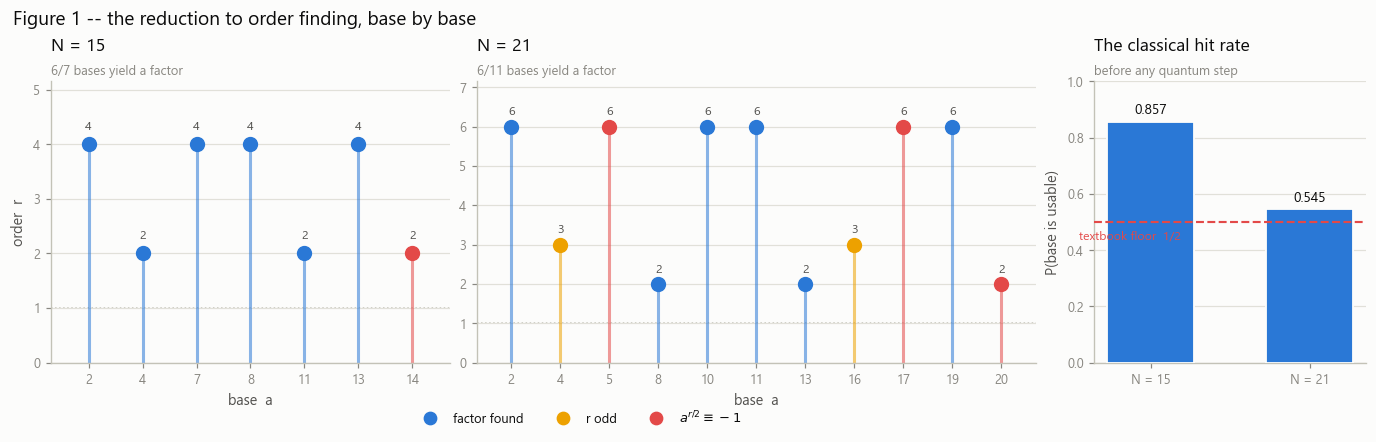

In [3]:
VERDICT_COLOR = {"ok": style.BLUE, "r odd": style.YELLOW,
                 "a^(r/2) = -1": style.RED}


def verdict_key(why, f):
    return "ok" if f else why


fig = plt.figure(figsize=(12.4, 3.7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.25, 1.75, 0.85])

for col, N in enumerate((15, 21)):
    ax = fig.add_subplot(gs[0, col])
    rows = TABLE[N]
    xs = np.arange(len(rows))
    for x, (a, r, why, f) in zip(xs, rows):
        c = VERDICT_COLOR[verdict_key(why, f)]
        ax.vlines(x, 0, r, color=c, lw=2.0, alpha=0.55, zorder=2)
        ax.plot([x], [r], "o", ms=9, color=c, zorder=3)
        ax.text(x, r + 0.22, str(r), ha="center", va="bottom", fontsize=8,
                color=style.INK_2)
    ax.axhline(1, color=style.AXIS, ls=":", lw=1.0, zorder=1)
    ax.set_xticks(xs)
    ax.set_xticklabels([str(a) for a, *_ in rows])
    ax.set_xlabel("base  a")
    ax.set_ylabel("order  r" if col == 0 else None)
    ax.set_ylim(0, max(r for _, r, _, _ in rows) + 1.15)
    ax.set_xlim(-0.7, len(rows) - 0.3)
    hits = sum(1 for *_, f in rows if f)
    style.title(ax, f"N = {N}", f"{hits}/{len(rows)} bases yield a factor")

handles = [plt.Line2D([], [], marker="o", ls="none", color=c, ms=8, label=l)
           for l, c in [("factor found", style.BLUE), ("r odd", style.YELLOW),
                        (r"$a^{r/2} \equiv -1$", style.RED)]]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.42, -0.06))

ax = fig.add_subplot(gs[0, 2])
rates = [sum(1 for *_, f in TABLE[N] if f) / len(TABLE[N]) for N in (15, 21)]
b = ax.bar(["N = 15", "N = 21"], rates, width=0.55, color=style.BLUE,
           edgecolor=style.SURFACE, lw=1.2, zorder=3)
ax.bar_label(b, fmt="%.3f", padding=3, fontsize=9, color=style.INK)
ax.axhline(0.5, color=style.RED, ls="--", lw=1.4, zorder=4)
ax.text(-0.45, 0.47, "textbook floor  1/2", fontsize=8, color=style.RED,
        ha="left", va="top")
ax.set_ylim(0, 1.0)
ax.set_ylabel("P(base is usable)")
style.title(ax, "The classical hit rate", "before any quantum step")

fig.suptitle("Figure 1 -- the reduction to order finding, base by base",
             fontsize=12.5, x=0.005, ha="left")
plt.show()

---

## Part 2 — the oracle is a permutation

The operator we want to estimate is

$$U_a\,|x\rangle = |a x \bmod N\rangle \quad (0 \le x < N),
\qquad U_a\,|x\rangle = |x\rangle \quad (N \le x < 2^{n}),$$

on $n = \lceil \log_2 N \rceil$ work qubits. The padding on the second line is not
cosmetic: multiplication mod $N$ is only defined on $\{0,\dots,N-1\}$, and the
register has $2^n \ge N$ slots. The leftover slots have to go *somewhere*, and
sending them to themselves is the only choice that keeps $U_a$ unitary.

$U_a$ is a **permutation matrix** — one 1 per row and column, no phases anywhere.
That is worth pausing on: the oracle contains no complex numbers at all. Every
phase in this algorithm is manufactured by the interference in Part 4, not stored
in the operator.

Because $\gcd(a,N)=1$, multiplication by $a$ is a bijection on the residues, so
$U_a$ decomposes into disjoint cycles, and the cycle through $x=1$ has length
exactly $r$. Hence $U_a^{\,r} = I$ on that cycle — and in fact on all of them,
since every cycle length divides $r$ for the residues coprime to $N$.

In [4]:
def perm_matrix(b, N, nw):
    """U_b as a dense permutation matrix on 2**nw basis states."""
    d = 2 ** nw
    P = np.zeros((d, d))
    for x in range(d):
        P[((b * x) % N) if x < N else x, x] = 1.0
    return P


def cmul_gate(b, N, nw):
    """Controlled-U_b as ONE block-diagonal UnitaryGate on 1 + nw qubits.

    Endianness, the live trap: Qiskit makes qarg 0 the LEAST significant bit of
    a gate's matrix. We append this as [control, *work], so the control is bit 0
    and the full index is  idx = c + 2 * x,  NOT  idx = x + 2**nw * c.  Writing
    the textbook block_diag(I, P) here gives a perfectly valid unitary that
    computes the wrong thing, with no error and no warning.
    """
    d = 2 ** nw
    M = np.zeros((2 * d, 2 * d))
    for x in range(d):
        M[2 * x, 2 * x] = 1.0                     # control 0: identity
        y = (b * x) % N if x < N else x
        M[2 * y + 1, 2 * x + 1] = 1.0             # control 1: multiply
    return UnitaryGate(M, label=f"*{b} mod {N}")


def cycles(b, N, nw):
    """Disjoint cycles of x -> b x mod N, padding fixed above N."""
    d, seen, out = 2 ** nw, set(), []
    for start in range(d):
        if start in seen:
            continue
        cyc, x = [], start
        while x not in seen:
            seen.add(x)
            cyc.append(x)
            x = (b * x) % N if x < N else x
        out.append(cyc)
    return out


N_DEMO, A_DEMO = 15, 7
NW_DEMO = int(np.ceil(np.log2(N_DEMO)))
P7 = perm_matrix(A_DEMO, N_DEMO, NW_DEMO)
R_DEMO = order(A_DEMO, N_DEMO)

print(f"N = {N_DEMO}, a = {A_DEMO}, r = {R_DEMO}, work qubits = {NW_DEMO}")
print("permutation matrix is real and 0/1:",
      np.array_equal(P7, P7.astype(bool).astype(float)))
print("unitary:", np.allclose(P7 @ P7.T, np.eye(2 ** NW_DEMO)))
for k in range(1, R_DEMO + 1):
    Pk = np.linalg.matrix_power(P7, k)
    print(f"  U^{k} == I ? {np.allclose(Pk, np.eye(2 ** NW_DEMO))}")
print("\ncycles of x -> 7x mod 15:")
for cyc in cycles(A_DEMO, N_DEMO, NW_DEMO):
    print("   ", " -> ".join(map(str, cyc)) + f" -> {cyc[0]}   (length {len(cyc)})")

N = 15, a = 7, r = 4, work qubits = 4
permutation matrix is real and 0/1: True
unitary: True
  U^1 == I ? False
  U^2 == I ? False
  U^3 == I ? False
  U^4 == I ? True

cycles of x -> 7x mod 15:
    0 -> 0   (length 1)
    1 -> 7 -> 4 -> 13 -> 1   (length 4)
    2 -> 14 -> 8 -> 11 -> 2   (length 4)
    3 -> 6 -> 12 -> 9 -> 3   (length 4)
    5 -> 5   (length 1)
    10 -> 10   (length 1)
    15 -> 15   (length 1)


### Figure 2 — the oracle, drawn twice

**Left:** the cycle structure of $x \mapsto 7x \bmod 15$ as a directed graph, the
16 basis states laid out on a circle. The cycle through $x = 1$ is drawn in blue
and is the one the algorithm rides; everything else is muted. Its length is $4$,
and that is $r$ — the number the whole notebook is chasing is *visible in this
picture*, which is the last time that will be true for any $N$ you care about.

The two fixed points are $x=0$ (times anything is still zero) and $x=15$ (the
padding slot, outside the modulus).

**Right, four panels:** $U_7^{\,k}$ for $k = 1,2,3,4$ as sparsity maps —
`part="nonzero"`, so an entry is either present or absent rather than "small".
The 1s march around and land back on the diagonal at $k = 4$. That is $U^r = I$
as a picture, and it is the *entire* reason phase estimation can work here: an
operator whose $r$-th power is the identity has eigenvalues that are $r$-th roots
of unity, and nothing else.

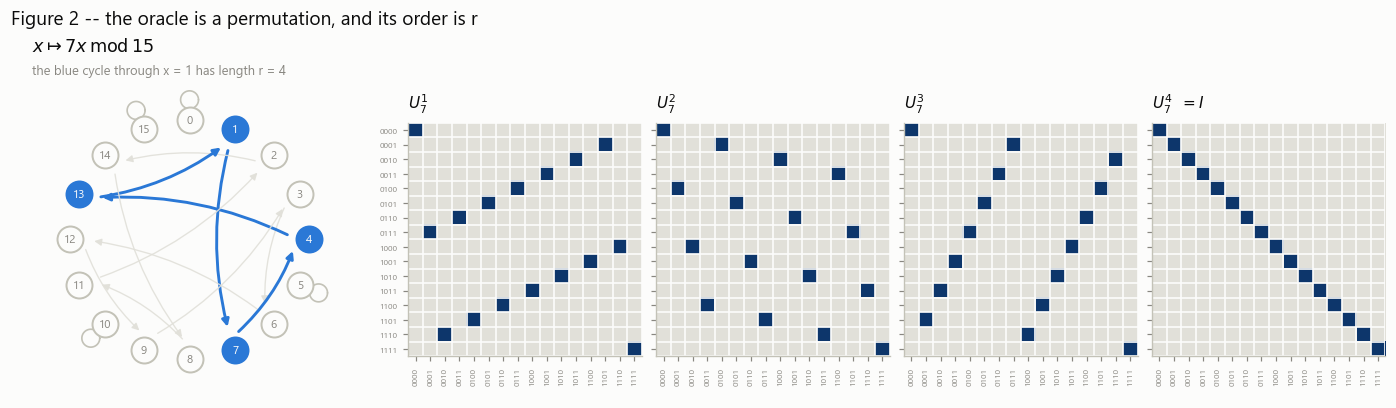

In [5]:
fig = plt.figure(figsize=(12.6, 3.6))
gs = fig.add_gridspec(1, 5, width_ratios=[1.55, 1, 1, 1, 1])

# ---- cycle graph
ax = fig.add_subplot(gs[0, 0])
d = 2 ** NW_DEMO
ang = -2 * np.pi * np.arange(d) / d + np.pi / 2
pos = np.c_[np.cos(ang), np.sin(ang)]
main = set(next(c for c in cycles(A_DEMO, N_DEMO, NW_DEMO) if 1 in c))

for x in range(d):
    y = (A_DEMO * x) % N_DEMO if x < N_DEMO else x
    hot = x in main
    if x == y:                                    # fixed point: a small loop
        cx, cy = pos[x] * 1.17
        lt = np.linspace(0, 2 * np.pi, 60)
        ax.plot(cx + 0.075 * np.cos(lt), cy + 0.075 * np.sin(lt),
                color=style.AXIS, lw=1.1, zorder=2)
        continue
    ax.annotate("", xy=pos[y] * 0.9, xytext=pos[x] * 0.9,
                arrowprops=dict(arrowstyle="-|>", lw=1.9 if hot else 0.9,
                                color=style.BLUE if hot else style.GRID,
                                shrinkA=7, shrinkB=8,
                                connectionstyle="arc3,rad=0.14",
                                alpha=1.0 if hot else 0.9))
for x in range(d):
    hot = x in main
    ax.plot(*pos[x], "o", ms=17, color=style.BLUE if hot else style.SURFACE,
            mec=style.BLUE if hot else style.AXIS, mew=1.3, zorder=5)
    ax.text(*pos[x], str(x), ha="center", va="center", fontsize=7.5,
            color=style.SURFACE if hot else style.MUTED, zorder=6,
            fontweight="medium")
ax.set_xlim(-1.32, 1.32)
ax.set_ylim(-1.32, 1.32)
ax.set_aspect("equal")
ax.axis("off")
style.title(ax, r"$x \mapsto 7x \,\mathrm{mod}\, 15$",
            "the blue cycle through x = 1 has length r = 4")

# ---- powers of U
for k in range(1, 5):
    ax = fig.add_subplot(gs[0, k])
    Pk = np.linalg.matrix_power(P7, k)
    grid.matrix(ax, Pk, part="nonzero", cbar=False, annot=False,
                tick_size=5.5, tick_rotation=90,
                title=(r"$U_7^{%d}$" % k) + ("  $= I$" if k == 4 else ""))
    if k > 1:
        ax.set_yticklabels([])

fig.suptitle("Figure 2 -- the oracle is a permutation, and its order is r",
             fontsize=12.5, x=0.005, ha="left")
plt.show()

---

## Part 3 — the eigenvectors, and the trick that makes this practical

Phase estimation needs an **eigenvector** of $U_a$ to push through the circuit.
The eigenvectors of interest are

$$|u_s\rangle \;=\; \frac{1}{\sqrt r}\sum_{k=0}^{r-1}
e^{-2\pi i\,sk/r}\,\bigl|a^{k} \bmod N\bigr\rangle,
\qquad
U_a\,|u_s\rangle \;=\; e^{2\pi i\,s/r}\,|u_s\rangle .$$

Each one carries the phase $s/r$, and $r$ is sitting in the denominator. Estimate
that phase, recover $r$.

**But you cannot prepare $|u_s\rangle$** — writing it down requires knowing $r$,
which is the thing you are trying to compute. This is where Shor's actual trick
lands, and it is a one-line miracle:

$$\frac{1}{\sqrt r}\sum_{s=0}^{r-1} |u_s\rangle \;=\; |1\rangle .$$

The sum telescopes: the $k=0$ term appears with coefficient $\frac1r\sum_s 1 = 1$,
and every $k \ne 0$ term appears with $\frac1r\sum_s e^{-2\pi i sk/r} = 0$. So the
*trivially preparable* state $|1\rangle$ — one `x` gate — is an equal superposition
of all $r$ eigenvectors. Run phase estimation on it and, by linearity, you get one
of the $r$ phases $s/r$, with $s$ uniform. You do not get to choose $s$, and Part 6
is about how much that costs.

The code below builds the $|u_s\rangle$ from the definition and checks all three
claims numerically: eigenvector, eigenvalue, and the telescoping sum.

In [6]:
def eigvec(s, a, N, nw):
    """|u_s> from the definition. Raw NumPy -- nothing quantum imported."""
    r = order(a, N)
    v = np.zeros(2 ** nw, dtype=complex)
    for k in range(r):
        v[pow(a, k, N)] += np.exp(-2j * np.pi * s * k / r)
    return v / np.sqrt(r)


US = [eigvec(s, A_DEMO, N_DEMO, NW_DEMO) for s in range(R_DEMO)]

print(f"|u_s> for N = {N_DEMO}, a = {A_DEMO}, r = {R_DEMO}")
for s, u in enumerate(US):
    lam_expected = np.exp(2j * np.pi * s / R_DEMO)
    Uu = P7 @ u
    print(f"  s = {s}:  norm = {np.linalg.norm(u):.6f}   "
          f"U|u_s> = exp(2 pi i * {s}/{R_DEMO}) |u_s| ? "
          f"{np.allclose(Uu, lam_expected * u)}   "
          f"phase/2pi = {np.angle(lam_expected) / (2 * np.pi) % 1:.4f}")

# orthonormal set
G = np.array([[np.vdot(u, w) for w in US] for u in US])
print("\northonormal:", np.allclose(G, np.eye(R_DEMO)))

# the telescoping identity
one = np.zeros(2 ** NW_DEMO, dtype=complex)
one[1] = 1.0
mix = sum(US) / np.sqrt(R_DEMO)
print("sum_s |u_s> / sqrt(r) == |1> :", np.allclose(mix, one))
print("  max |difference| =", float(np.max(np.abs(mix - one))))

|u_s> for N = 15, a = 7, r = 4
  s = 0:  norm = 1.000000   U|u_s> = exp(2 pi i * 0/4) |u_s| ? True   phase/2pi = 0.0000
  s = 1:  norm = 1.000000   U|u_s> = exp(2 pi i * 1/4) |u_s| ? True   phase/2pi = 0.2500
  s = 2:  norm = 1.000000   U|u_s> = exp(2 pi i * 2/4) |u_s| ? True   phase/2pi = 0.5000
  s = 3:  norm = 1.000000   U|u_s> = exp(2 pi i * 3/4) |u_s| ? True   phase/2pi = 0.7500

orthonormal: True
sum_s |u_s> / sqrt(r) == |1> : True
  max |difference| = 1.1704836984704332e-16


### Figure 3 — where the answer is hiding

**Top left:** the eigenvalues of $U_7$ on the unit circle — $e^{2\pi i s/4}$, the
4th roots of unity, and the *only* phases the counting register can report. Their
angular spacing is $2\pi/r$, so "measure the phase" and "measure $r$" are the same
request.

All sixteen eigenvalues land on those four points, which is why each is labelled
with a multiplicity rather than drawn separately. That is not a coincidence:
Figure 2 showed the cycles have lengths $4,4,4,1,1,1,1$, a cycle of length $L$
contributes the $L$-th roots of unity, and every one of these $L$ divides $4$. The
$|u_s\rangle$ below pick out the one cycle $|1\rangle$ actually lives on.

**Top right:** the overlap $|\langle u_s | 1\rangle|^2$ for each $s$ — flat at
$1/r = 0.25$. That flatness *is* the "uniform $s$" claim, and it is why $s=0$
(useless, phase 0, tells you nothing) shows up a quarter of the time.

**Bottom row:** the four eigenvectors as the repo's signature bars — height is
$|{\rm amplitude}|$, hue is phase, clock hands repeat the phase for anyone reading
in greyscale. Each one lives on exactly the four states of the blue cycle
$\{1,4,7,13\}$ with equal magnitude $1/2$, and the *only* thing distinguishing
them is how fast the phase winds around the cycle: $s=0$ is all one colour, and
$s=1,2,3$ wind once, twice and three times as they go round.

One thing to read carefully — the bars are ordered by **basis index**, but the
winding happens in **cycle order**, which is $1 \to 7 \to 4 \to 13$. So $s=2$,
which alternates sign along the cycle, appears in the plot as two-and-two rather
than as a strict alternation. The picture is faithful; the x-axis is just not the
order the phase walks in.

The fifth panel adds them up. Three quarters of the ink cancels exactly and what
survives is a single bar on $|0001\rangle$ — the state we can actually prepare
with one `x` gate.

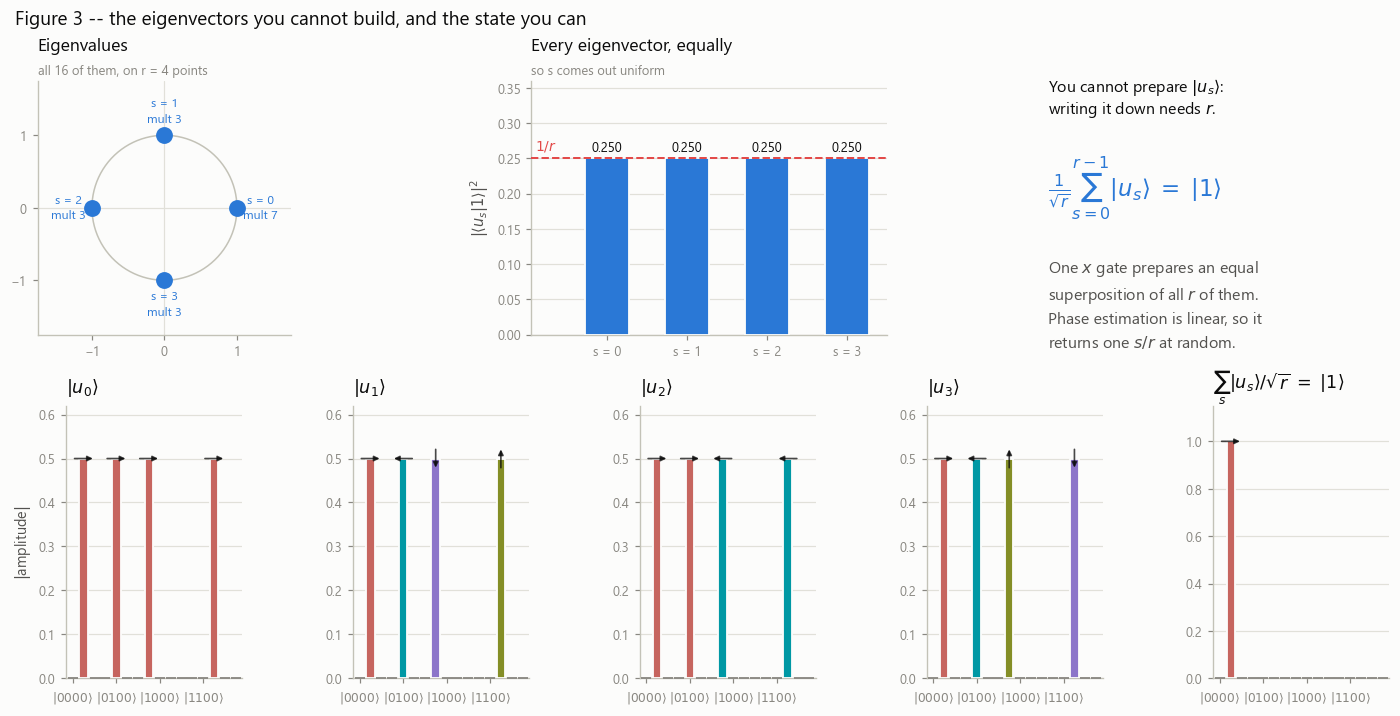

In [7]:
fig = plt.figure(figsize=(12.6, 6.4))
outer = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.05], hspace=0.42)
top = outer[0].subgridspec(1, 3, width_ratios=[1, 1.25, 1.2], wspace=0.35)

# ---- eigenvalues on the circle
ax = fig.add_subplot(top[0, 0])
th = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(th), np.sin(th), color=style.AXIS, lw=1.0, zorder=1)
lam = np.exp(2j * np.pi * np.arange(R_DEMO) / R_DEMO)
all_eig = np.linalg.eigvals(P7)
mult = [int(np.sum(np.isclose(all_eig, l, atol=1e-9))) for l in lam]
ax.plot(lam.real, lam.imag, "o", ms=10, color=style.BLUE, zorder=4)
for s in range(R_DEMO):
    ax.text(lam[s].real * 1.33, lam[s].imag * 1.33,
            f"s = {s}\nmult {mult[s]}", ha="center", va="center",
            fontsize=8, color=style.BLUE, linespacing=1.4)
ax.set_aspect("equal")
ax.set_xlim(-1.75, 1.75)
ax.set_ylim(-1.75, 1.75)
ax.axhline(0, color=style.GRID, lw=0.8, zorder=0)
ax.axvline(0, color=style.GRID, lw=0.8, zorder=0)
ax.grid(False)
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1])
style.title(ax, "Eigenvalues", f"all {2 ** NW_DEMO} of them, on r = {R_DEMO} points")

# ---- overlaps
ax = fig.add_subplot(top[0, 1])
ov = np.array([abs(np.vdot(u, one)) ** 2 for u in US])
b = ax.bar(np.arange(R_DEMO), ov, width=0.55, color=style.BLUE,
           edgecolor=style.SURFACE, lw=1.2, zorder=3)
ax.bar_label(b, fmt="%.3f", padding=3, fontsize=8.5, color=style.INK)
ax.axhline(1 / R_DEMO, color=style.RED, ls="--", lw=1.3, zorder=4)
ax.text(-0.90, 1 / R_DEMO + 0.008, "$1/r$", color=style.RED, fontsize=9,
        ha="left", va="bottom")
ax.set_xticks(range(R_DEMO))
ax.set_xticklabels([f"s = {s}" for s in range(R_DEMO)])
ax.set_xlim(-0.95, R_DEMO - 0.5)
ax.set_ylim(0, 0.36)
ax.set_ylabel(r"$|\langle u_s | 1 \rangle|^2$")
style.title(ax, "Every eigenvector, equally", "so s comes out uniform")

# ---- the punchline in words
ax = fig.add_subplot(top[0, 2])
ax.axis("off")
ax.text(0.0, 1.02,
        r"You cannot prepare $|u_s\rangle$:" + "\nwriting it down needs $r$.",
        transform=ax.transAxes, va="top", fontsize=10.5, color=style.INK)
ax.text(0.0, 0.58,
        r"$\frac{1}{\sqrt{r}}\sum_{s=0}^{r-1}|u_s\rangle \;=\; |1\rangle$",
        transform=ax.transAxes, va="center", fontsize=15, color=style.BLUE)
ax.text(0.0, 0.30,
        "One $x$ gate prepares an equal\nsuperposition of all $r$ of them.\n"
        "Phase estimation is linear, so it\nreturns one $s/r$ at random.",
        transform=ax.transAxes, va="top", fontsize=10.5, color=style.INK_2,
        linespacing=1.5)

# ---- the eigenvectors themselves
bot = outer[1].subgridspec(1, 5, wspace=0.30)
for s in range(R_DEMO):
    ax = fig.add_subplot(bot[0, s])
    grid.amp_bars(ax, US[s], ylim=0.62, tick_every=4,
                  ylabel=r"$|$amplitude$|$" if s == 0 else None)
    style.title(ax, f"$|u_{s}\\rangle$")
ax = fig.add_subplot(bot[0, 4])
grid.amp_bars(ax, mix, ylim=1.15, tick_every=4, ylabel=None)
style.title(ax, r"$\sum_s |u_s\rangle / \sqrt{r} \;=\; |1\rangle$")

fig.suptitle("Figure 3 -- the eigenvectors you cannot build, and the state you can",
             fontsize=12.5, x=0.005, ha="left")
plt.show()

---

## Part 4 — the circuit, and what it is supposed to output

Structurally this is B23's phase estimation with a different $U$:

1. $t$ **counting** qubits into uniform superposition with Hadamards.
2. The **work** register set to $|1\rangle$ with one `x`.
3. For each counting qubit $j$, a controlled $U_a^{2^j}$. We never build a power
   of a circuit: $a^{2^j} \bmod N$ is a *classical* exponentiation, computed with
   `pow(a, 2**j, N)`, and we build the single multiplier for that residue. This
   is the "repeated squaring is free classically" step, and it is why the circuit
   is $O(t)$ oracles rather than $O(2^t)$.
4. Inverse QFT on the counting register, then measure.

Two implementation notes that cost real time to discover.

**We use `QFTGate(t).inverse()` directly, not `phase_estimation()`.** B23 showed
that Qiskit's `phase_estimation()` appends an explicit reversal permutation after
its inverse QFT, so its measured integer is the bit-reversal of the one the
textbook formula predicts. Rolling the two lines by hand keeps the convention
identical to A11's and to B23's fixed version, and means the continued-fractions
code in Part 6 reads $m$ the way the maths says.

**The controlled multiplier's control is the LOW bit of its matrix.** Qiskit makes
qarg 0 the least significant bit, so appending `[control, *work]` means the matrix
index is $c + 2x$, not $x + 2^n c$. Building the textbook `block_diag(I, P)`
instead produces a valid unitary that does nothing useful — every shot comes back
$00000000$, with no error raised. That is not a hypothetical; it is what the first
draft of this notebook did.

### The closed form we will check against

We already know the answer analytically. $|1\rangle$ is an equal mix of $r$
eigenvectors, phase estimation is linear, and A11 derived the single-eigenvector
output as a Dirichlet kernel. So with $T = 2^t$,

$$P(m) \;=\; \frac{1}{r}\sum_{s=0}^{r-1}
\frac{1}{T^2}\,
\frac{\sin^2\!\bigl(\pi T (m/T - s/r)\bigr)}{\sin^2\!\bigl(\pi (m/T - s/r)\bigr)} .$$

That is $r$ copies of A11's leakage skirt, centred on $s/r$ and averaged. Having
it in closed form is what lets Part 7 sweep every base at every $t$ in NumPy
instead of running two hundred statevector simulations.

In [8]:
def order_circuit(a, N, t, *, measure=False):
    """QPE on U_a with |1> in the work register. Returns (circuit, nw)."""
    nw = int(np.ceil(np.log2(N)))
    up = QuantumRegister(t, "count")
    lo = QuantumRegister(nw, "work")
    qc = QuantumCircuit(up, lo)
    qc.h(up)
    qc.x(lo[0])                                   # |1>, little-endian
    for j in range(t):
        b = pow(a, 2 ** j, N)                     # classical repeated squaring
        if b != 1:                                # b == 1 is the identity gate
            qc.append(cmul_gate(b, N, nw), [up[j], *lo])
    qc.append(QFTGate(t).inverse(), up)           # NOT phase_estimation(): B23
    if measure:
        c = ClassicalRegister(t, "c")
        qc.add_register(c)
        qc.measure(up, c)
    return qc, nw


def qiskit_probs(a, N, t):
    """Exact marginal of the counting register, from the statevector."""
    qc, nw = order_circuit(a, N, t)
    p = np.abs(Statevector(qc).data) ** 2
    # little-endian: index = m + 2**t * work, so reshape (work, m) and sum work
    return p.reshape(2 ** nw, 2 ** t).sum(axis=0)


def dirichlet_probs(r, t):
    """The closed form: r Dirichlet kernels centred on s/r, averaged."""
    T = 2 ** t
    m = np.arange(T)
    out = np.zeros(T)
    for s in range(r):
        dd = m / T - s / r
        sd = np.sin(np.pi * dd)
        on = np.abs(sd) < 1e-12                   # kernel peak: 0/0 -> T**2
        out += np.where(on, float(T) ** 2,
                        np.sin(np.pi * T * dd) ** 2
                        / np.where(on, 1.0, sd ** 2)) / T ** 2
    return out / r


T15, T21 = 8, 9
CASES = [(15, 7, T15), (21, 2, T21)]

for N, a, t in CASES:
    qc, nw = order_circuit(a, N, t)
    tq = transpile(qc, basis_gates=["u", "cx"], optimization_level=1,
                   seed_transpiler=SEED)
    p = qiskit_probs(a, N, t)
    q = dirichlet_probs(order(a, N), t)
    print(f"N = {N}, a = {a}, r = {order(a, N)}, t = {t}, "
          f"qubits = {t + nw} ({t} count + {nw} work)")
    print(f"    oracles applied     : {sum(1 for j in range(t) if pow(a, 2**j, N) != 1)}"
          f"  of {t} counting qubits")
    print(f"    depth / CX after transpile : {tq.depth()} / {tq.count_ops().get('cx', 0)}")
    print(f"    Qiskit vs closed form      : allclose "
          f"{np.allclose(p, q, atol=1e-9)}, max diff {np.max(np.abs(p - q)):.2e}")
    top = np.argsort(p)[::-1][:order(a, N)]
    print("    most likely m       : "
          + ", ".join(f"{int(m)} (p={p[m]:.4f})" for m in sorted(top)))
    off = p.copy()
    off[top] = 0.0
    print(f"    largest off-peak p  : {off.max():.2e}   "
          f"(mass off the peaks: {off.sum():.4f})\n")

N = 15, a = 7, r = 4, t = 8, qubits = 12 (8 count + 4 work)
    oracles applied     : 2  of 8 counting qubits
    depth / CX after transpile : 923 / 539
    Qiskit vs closed form      : allclose True, max diff 6.11e-16
    most likely m       : 0 (p=0.2500), 64 (p=0.2500), 128 (p=0.2500), 192 (p=0.2500)
    largest off-peak p  : 1.02e-34   (mass off the peaks: 0.0000)



N = 21, a = 2, r = 6, t = 9, qubits = 14 (9 count + 5 work)
    oracles applied     : 9  of 9 counting qubits


    depth / CX after transpile : 17811 / 9120
    Qiskit vs closed form      : allclose True, max diff 5.44e-15
    most likely m       : 0 (p=0.1667), 85 (p=0.1140), 171 (p=0.1140), 256 (p=0.1667), 341 (p=0.1140), 427 (p=0.1140)
    largest off-peak p  : 2.85e-02   (mass off the peaks: 0.2107)



### Figure 4 — a clean comb and a dirty one

Blue fill is the exact counting-register distribution pulled out of Qiskit's
statevector; the dashed black line is the closed form above; the red verticals
sit at the true $s/r$ positions. **Top row is linear, bottom row is the same data
on a log scale** — which is where the interesting part lives, because on a linear
axis "leakage" and "exactly zero" look identical.

**Left, $N=15$, $a=7$, $r=4$, $t=8$.** $r$ divides $T = 256$, so every $s/r$ is
*exactly* representable as an 8-bit fraction and the distribution is four delta
spikes of height $1/4$ at $m = 0, 64, 128, 192$. Zero leakage. This is the picture
tutorials print, and it is a special case: it happens because 15's orders are
powers of two.

**Right, $N=21$, $a=2$, $r=6$, $t=9$.** Now $s/6$ is not representable in binary
for $s \notin \{0,3\}$, so four of the six peaks smear into A11's Dirichlet
skirts. $m=0$ and $m=256$ ($=T/2$, i.e. $s/r = 1/2$) stay sharp at the full
$1/6 = 0.167$; the four smeared ones peak at only $0.114$, so about **a third** of
each one's mass has left its own bin.

The bottom-right panel is the payoff: five orders of magnitude of $\mathrm{sinc}^2$
skirt, filling *every* value of $m$, with the closed form tracking each wiggle.
Compare bottom-left, where the same axis shows the $N=15$ distribution pinned flat
on the $10^{-12}$ clip — those bins are not "small", they are zero to machine
precision (the printout above gives the largest off-peak value). Leakage is not
noise; it is a deterministic, computable, and in this case rather beautiful
function.

That smearing is the whole reason $t$ has to be generous, and Part 7 measures the
price.

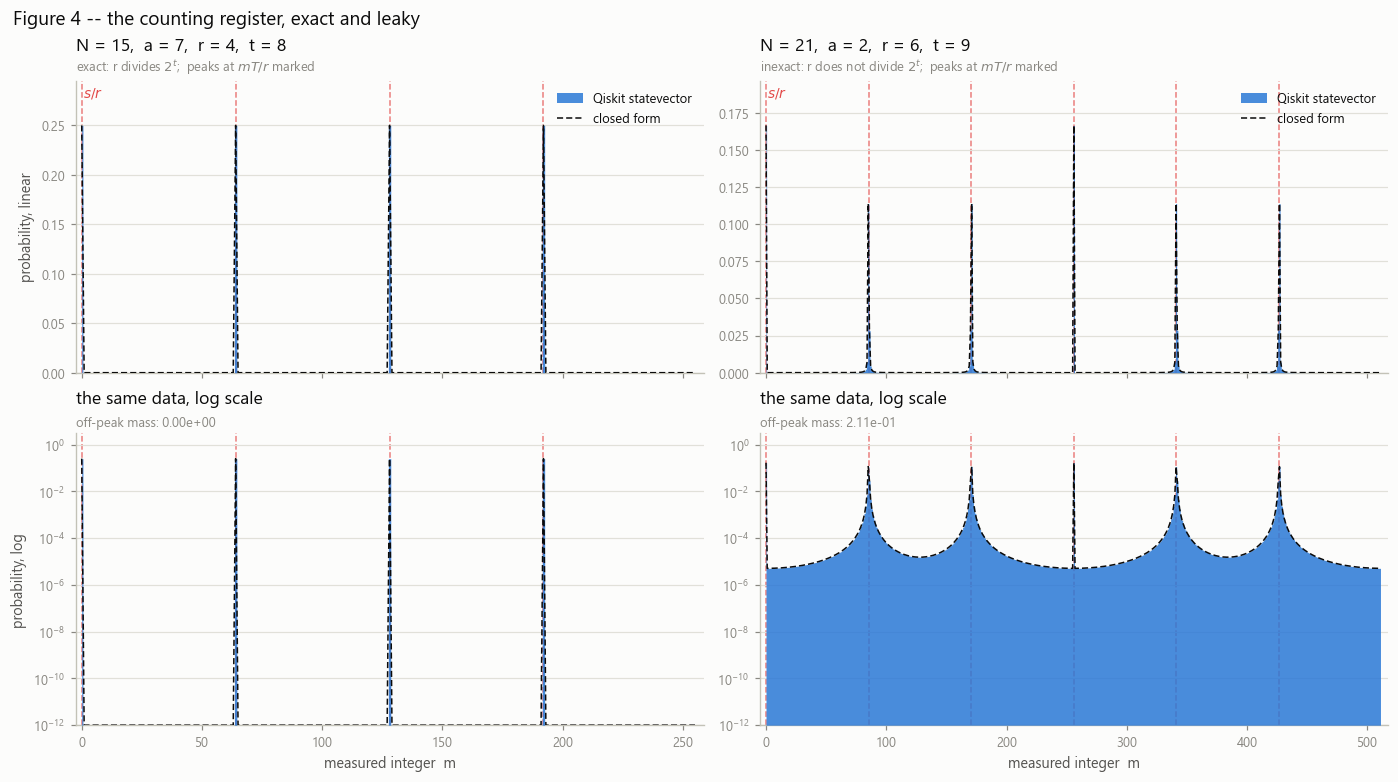

In [9]:
FLOOR = 1e-12

fig, axes = plt.subplots(2, 2, figsize=(12.6, 7.0), sharex="col")

for col, (N, a, t) in enumerate(CASES):
    r, T = order(a, N), 2 ** t
    p = qiskit_probs(a, N, t)
    q = dirichlet_probs(r, t)
    m = np.arange(T)
    for row in (0, 1):
        ax = axes[row, col]
        for s in range(r):
            ax.axvline(s * T / r, color=style.RED, ls="--", lw=1.0, alpha=0.7,
                       zorder=1)
        ax.fill_between(m, FLOOR, np.maximum(p, FLOOR), step="mid",
                        color=style.BLUE, alpha=0.85, lw=0, zorder=3,
                        label="Qiskit statevector")
        ax.plot(m, np.maximum(q, FLOOR), color=style.INK, lw=1.0,
                ls=(0, (4, 2)), zorder=4, label="closed form")
        ax.set_xlim(-T * 0.01, T * 1.01)
    ax0, ax1 = axes[0, col], axes[1, col]
    ax0.set_ylim(0, max(p.max(), q.max()) * 1.18)
    ax0.legend(loc="upper right", fontsize=8.5)
    ax0.text(0.012, 0.985, r"$s/r$", transform=ax0.transAxes, va="top",
             fontsize=9, color=style.RED)
    ax1.set_yscale("log")
    ax1.set_ylim(FLOOR, 3.0)
    ax1.set_xlabel("measured integer  m")
    if col == 0:
        ax0.set_ylabel("probability, linear")
        ax1.set_ylabel("probability, log")
    exact = ("exact: r divides $2^t$" if T % r == 0
             else "inexact: r does not divide $2^t$")
    style.title(ax0, f"N = {N},  a = {a},  r = {r},  t = {t}",
                f"{exact};  peaks at $mT/r$ marked")
    style.title(ax1, "the same data, log scale",
                "off-peak mass: %.2e" % (p.sum() - np.sort(p)[-r:].sum()))

fig.suptitle("Figure 4 -- the counting register, exact and leaky",
             fontsize=12.5, x=0.005, ha="left")
plt.show()

---

## Part 5 — real shots

Part 4 read the statevector, which no hardware will ever let you do. Here is the
same circuit through `SamplerV2` with 4096 shots, which is the measurement you
would actually have.

Two things are worth drawing rather than tabulating. First the **raw shot
record** — one row per shot, one pixel per counting bit — because the histogram
throws away exactly the thing that makes this hard: individual runs give
individual integers, and you have to decide what to do with each one. Second the
counts against the exact distribution, with **binomial error bars**
$\sigma = \sqrt{p(1-p)/n}$, which are real uncertainties computed from the shot
record. (Contrast Aer's `EstimatorV2`, whose `stds` field is fabricated from the
`precision` you passed in — see CLAUDE.md.)

In [10]:
SHOTS = 4096
N_S, A_S, T_S = 15, 7, T15

qc_m, nw_s = order_circuit(A_S, N_S, T_S, measure=True)
backend = backends.get_backend()
tqc = transpile(qc_m, backend, optimization_level=1, seed_transpiler=SEED)
res = backends.sampler(shots=SHOTS, seed=SEED).run([tqc]).result()
counts = res[0].data.c.get_counts()            # register is named "c"

meas = np.zeros(2 ** T_S)
for bits, n in counts.items():
    meas[int(bits, 2)] = n
p_meas = meas / SHOTS
sig = np.sqrt(np.maximum(p_meas * (1 - p_meas), 0) / SHOTS)
p_exact = qiskit_probs(A_S, N_S, T_S)

print(f"N = {N_S}, a = {A_S}, t = {T_S}, {SHOTS} shots, "
      f"{len(counts)} distinct outcomes seen")
print(f"{'m':>5} {'bits':>10} {'shots':>6} {'measured':>9} {'+/-':>7} "
      f"{'exact':>9} {'pull':>6}")
for m in sorted(np.flatnonzero(meas), key=lambda k: -meas[k])[:8]:
    pull = (p_meas[m] - p_exact[m]) / max(sig[m], 1e-12)
    print(f"{m:>5} {format(m, f'0{T_S}b'):>10} {int(meas[m]):>6} "
          f"{p_meas[m]:>9.4f} {sig[m]:>7.4f} {p_exact[m]:>9.4f} {pull:>6.2f}")
print("\n'pull' is (measured - exact) / sigma. All within a couple of sigma,")
print("which is what 4096 shots of a four-outcome distribution should look like.")

N = 15, a = 7, t = 8, 4096 shots, 4 distinct outcomes seen
    m       bits  shots  measured     +/-     exact   pull
   64   01000000   1059    0.2585  0.0068    0.2500   1.25
  128   10000000   1037    0.2532  0.0068    0.2500   0.47
    0   00000000   1000    0.2441  0.0067    0.2500  -0.87
  192   11000000   1000    0.2441  0.0067    0.2500  -0.87

'pull' is (measured - exact) / sigma. All within a couple of sigma,
which is what 4096 shots of a four-outcome distribution should look like.


### Figure 5 — the randomness, before it is averaged away

**Left:** the first 64 shots as a bitmap, one row per shot, one column per
counting qubit, blue = 1. Read the two leftmost columns (`q7`, `q6`, the high
bits): they are the only ones that ever fire, and they fire independently — which
is precisely the statement that the outcome is one of $\{0, 64, 128, 192\}$
chosen uniformly. The six low columns are dead, because $r = 4$ divides $T$ and
there is no leakage to fill them.

This picture is the honest one: *one shot gives you one integer.* Everything
downstream — continued fractions, the retry loop — exists to deal with that.

**Right:** counts against the exact distribution with binomial error bars. Four
outcomes, each $\approx 0.25$, all agreeing within about a standard deviation.

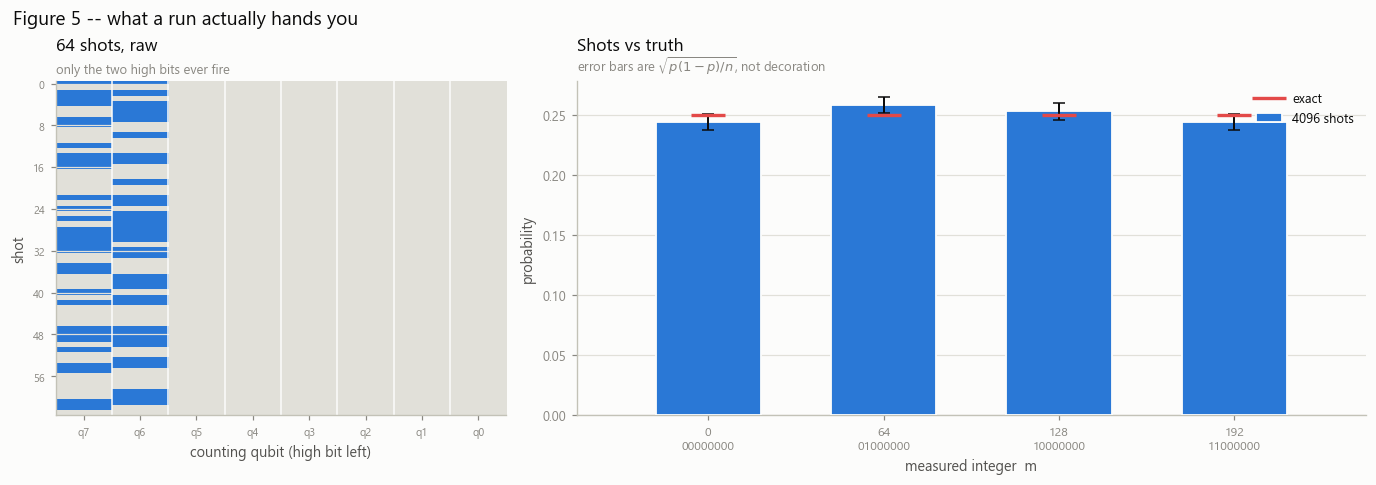

In [11]:
bit_rows = []
for bits, n in counts.items():
    bit_rows.extend([[int(ch) for ch in bits]] * n)
bit_rows = np.array(bit_rows)
bit_rows = bit_rows[rng.permutation(len(bit_rows))[:64]]

fig = plt.figure(figsize=(12.4, 4.3))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.75])

ax = fig.add_subplot(gs[0, 0])
grid.bit_record(ax, bit_rows,
                col_labels=[f"q{i}" for i in range(T_S - 1, -1, -1)],
                row_every=8, xlabel="counting qubit (high bit left)")
style.title(ax, "64 shots, raw", "only the two high bits ever fire")

ax = fig.add_subplot(gs[0, 1])
seen = np.argsort(meas)[::-1][:8]
seen = np.sort(seen[meas[seen] > 0])
x = np.arange(len(seen))
ax.bar(x, p_meas[seen], width=0.6, color=style.BLUE, edgecolor=style.SURFACE,
       lw=1.2, zorder=3, label=f"{SHOTS} shots")
ax.errorbar(x, p_meas[seen], yerr=sig[seen], fmt="none", ecolor=style.INK,
            elinewidth=1.3, capsize=4, zorder=5)
ax.plot(x, p_exact[seen], ls="none", marker="_", ms=22, mew=2.2,
        color=style.RED, zorder=6, label="exact")
ax.set_xticks(x)
ax.set_xticklabels([f"{int(m)}\n{format(int(m), f'0{T_S}b')}" for m in seen],
                   fontsize=8)
ax.set_xlim(-0.75, len(seen) - 0.25)
ax.set_xlabel("measured integer  m")
ax.set_ylabel("probability")
ax.legend(loc="upper right", fontsize=8.5)
style.title(ax, "Shots vs truth", r"error bars are $\sqrt{p(1-p)/n}$, not decoration")

fig.suptitle("Figure 5 -- what a run actually hands you",
             fontsize=12.5, x=0.005, ha="left")
plt.show()

---

## Part 6 — continued fractions, and which measurements are worth anything

A run hands you an integer $m$. What you want is $r$, via

$$\frac{m}{2^t} \;\approx\; \frac{s}{r},
\qquad 0 \le s < r < N .$$

The continued-fraction expansion of $m/2^t$ produces the sequence of best rational
approximations with bounded denominator, and the theorem says: if
$|m/2^t - s/r| < 1/(2r^2)$, then $s/r$ is one of them. Since $r < N$, taking
$2^t > N^2$ guarantees the resolution is fine enough — that is where the "use
$t \approx 2n$ counting qubits" rule comes from. Python's `Fraction.limit_denominator`
*is* the continued-fraction algorithm, so this is one line.

There is a failure mode built into the mathematics, and it has nothing to do with
noise or leakage:

> **If $\gcd(s, r) \ne 1$, the fraction $s/r$ arrives already reduced, and you
> recover $r/\gcd(s,r)$ — a divisor of $r$, not $r$.**

$s$ is uniform on $\{0,\dots,r-1\}$, so the probability that it is coprime to $r$
is $\varphi(r)/r$, Euler's totient over $r$. That is a hard ceiling on the success
of a single run, and it is not close to 1: for $r=6$ it is $2/6 = 1/3$. Note that
$s = 0$ is always a failure — it reports $r = 1$ and tells you nothing — and it
happens $1/r$ of the time.

Real implementations paper over this by running twice and taking the lcm of the
two denominators. We will measure both the naive and the lcm version.

In [12]:
def recover_r(m, t, N):
    """Continued fractions: best denominator < N approximating m / 2**t."""
    return Fraction(m, 2 ** t).limit_denominator(N - 1).denominator


def totient(n):
    return sum(1 for k in range(1, n + 1) if gcd(k, n) == 1)


for N, a, t in CASES:
    r = order(a, N)
    p = dirichlet_probs(r, t)
    good = np.array([recover_r(m, t, N) == r for m in range(2 ** t)])
    print(f"N = {N}, a = {a}, r = {r}, t = {t}")
    print(f"    P(continued fractions returns r) = {p[good].sum():.4f}")
    print(f"    ceiling phi(r)/r                 = "
          f"{totient(r)}/{r} = {totient(r) / r:.4f}")
    print("    what each peak reports:")
    for s in range(r):
        m = int(round(s * 2 ** t / r))
        rr = recover_r(m, t, N)
        note = "OK" if rr == r else f"divisor (gcd(s,r) = {gcd(s, r) or r})"
        print(f"      s = {s}: m = {m:>4} -> m/2^t = "
              f"{Fraction(m, 2 ** t)} -> r_hat = {rr:>2}   {note}")
    print()

N = 15, a = 7, r = 4, t = 8
    P(continued fractions returns r) = 0.5000
    ceiling phi(r)/r                 = 2/4 = 0.5000
    what each peak reports:
      s = 0: m =    0 -> m/2^t = 0 -> r_hat =  1   divisor (gcd(s,r) = 4)
      s = 1: m =   64 -> m/2^t = 1/4 -> r_hat =  4   OK
      s = 2: m =  128 -> m/2^t = 1/2 -> r_hat =  2   divisor (gcd(s,r) = 2)
      s = 3: m =  192 -> m/2^t = 3/4 -> r_hat =  4   OK

N = 21, a = 2, r = 6, t = 9
    P(continued fractions returns r) = 0.3084
    ceiling phi(r)/r                 = 2/6 = 0.3333
    what each peak reports:
      s = 0: m =    0 -> m/2^t = 0 -> r_hat =  1   divisor (gcd(s,r) = 6)
      s = 1: m =   85 -> m/2^t = 85/512 -> r_hat =  6   OK
      s = 2: m =  171 -> m/2^t = 171/512 -> r_hat =  3   divisor (gcd(s,r) = 2)
      s = 3: m =  256 -> m/2^t = 1/2 -> r_hat =  2   divisor (gcd(s,r) = 3)
      s = 4: m =  341 -> m/2^t = 341/512 -> r_hat =  3   divisor (gcd(s,r) = 2)
      s = 5: m =  427 -> m/2^t = 427/512 -> r_hat =  6   OK


### Figure 6 — the whole post-processing map, all $2^t$ inputs at once

For every possible measurement $m$ on the x-axis, the dot shows what continued
fractions returns for it. Blue means it returns the true $r$; grey means it
returns something else (usually a proper divisor, or 1 from $m$ near 0).

Underneath, the probability $P(m)$ is shaded in **blue where post-processing
succeeds and red where it fails**, so the success rate quoted in each subtitle is
literally the blue area. Nothing is hidden in an average: you can see which spikes
pay off and which are wasted runs.

Left ($N=15$, $r=4$): the map is a step function with wide flat plateaus, and the
four spikes of probability land on $m = 0, 64, 128, 192$. Two of them ($s = 1, 3$)
sit on blue, two ($s = 0, 2$) sit on grey — $\gcd(s,4) \ne 1$ for $s \in \{0,2\}$.
Exactly $1/2$, and no amount of extra $t$ changes it.

Right ($N=21$, $r=6$): the same structure but the probability is smeared, so a
peak that sits on a *narrow* blue plateau loses part of its mass to the grey
either side of it. This is where leakage costs money — it is not that the answer
is wrong, it is that some of the probability lands on $m$ values whose best
rational approximation has the wrong denominator.

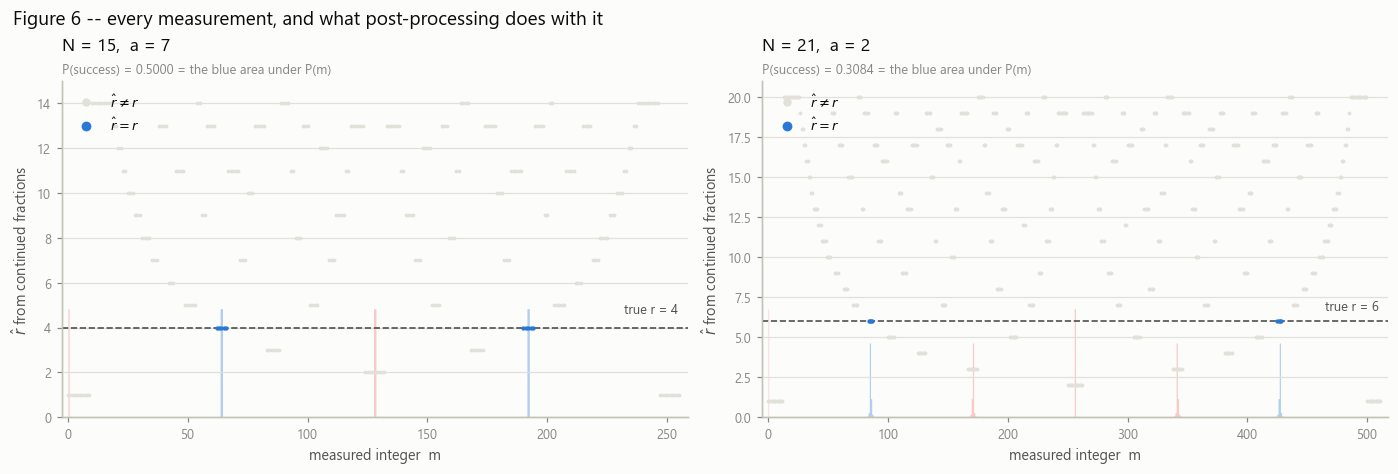

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2))

for ax, (N, a, t) in zip(axes, CASES):
    r, T = order(a, N), 2 ** t
    p = dirichlet_probs(r, t)
    m = np.arange(T)
    rhat = np.array([recover_r(int(mm), t, N) for mm in m])
    ok = rhat == r

    ax2 = ax.twinx()
    ax2.fill_between(m, 0, np.where(ok, p, 0.0), step="mid", color=style.BLUE,
                     alpha=0.35, lw=0, zorder=1)
    ax2.fill_between(m, 0, np.where(~ok, p, 0.0), step="mid", color=style.RED,
                     alpha=0.28, lw=0, zorder=1)
    ax2.set_ylim(0, p.max() * 3.1)
    ax2.set_yticks([])
    ax2.grid(False)

    ax.plot(m[~ok], rhat[~ok], ".", ms=3.0, color=style.GRID, zorder=3,
            rasterized=True, label=r"$\hat r \neq r$")
    ax.plot(m[ok], rhat[ok], ".", ms=3.6, color=style.BLUE, zorder=4,
            rasterized=True, label=r"$\hat r = r$")
    ax.axhline(r, color=style.INK_2, ls="--", lw=1.1, zorder=2)
    ax.text(T * 0.995, r + 0.5, f"true r = {r}", color=style.INK_2,
            fontsize=8.5, ha="right", va="bottom")
    ax.set_xlim(-T * 0.01, T * 1.01)
    ax.set_ylim(0, N)
    ax.set_xlabel("measured integer  m")
    ax.set_ylabel(r"$\hat r$ from continued fractions")
    ax.legend(loc="upper left", fontsize=8.5, markerscale=3)
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    style.title(ax, f"N = {N},  a = {a}",
                f"P(success) = {p[ok].sum():.4f} = the blue area under P(m)")

fig.suptitle("Figure 6 -- every measurement, and what post-processing does with it",
             fontsize=12.5, x=0.005, ha="left")
plt.show()

---

## Part 7 — the honest success rate

Now put it together and sweep. For each base and each $t$, the exact probability
that **one run** of (QPE + continued fractions) returns the true $r$ is
$\sum_{m\,:\,\hat r(m) = r} P(m)$, and $P(m)$ is the closed form from Part 4. No
sampling, no error bars needed — these are exact numbers.

Two effects fight each other as $t$ grows:

- More counting qubits sharpen the peaks, so less mass leaks onto $m$ values with
  the wrong denominator. This helps, and saturates quickly.
- Nothing whatsoever fixes $\gcd(s,r) \ne 1$. That failure is in the algorithm,
  not the resolution.

So the curves rise and then flatten against $\varphi(r)/r$, which is the honest
answer to "how likely is one run to work".

In [14]:
def qpe_success(a, N, t):
    """Exact P(one run of QPE + continued fractions returns the true r)."""
    r = order(a, N)
    p = dirichlet_probs(r, t)
    ok = np.array([recover_r(m, t, N) == r for m in range(2 ** t)])
    return float(p[ok].sum())


TS = {15: range(2, 13), 21: range(2, 13)}
curves = {}
for N in (15, 21):
    ba = bases(N)
    curves[N] = {
        "t": list(TS[N]),
        "mean": [float(np.mean([qpe_success(a, N, t) for a in ba]))
                 for t in TS[N]],
        "ceiling": float(np.mean([totient(order(a, N)) / order(a, N)
                                  for a in ba])),
    }
    c = curves[N]
    print(f"N = {N}:  mean P(recover r) over all {len(ba)} bases")
    print("   " + "  ".join(f"t={t}:{v:.3f}" for t, v in
                            zip(c["t"], c["mean"])))
    print(f"   ceiling  E[phi(r)/r] = {c['ceiling']:.4f}\n")

# End-to-end: P(one run factors N), folding in the classical failures too.
for N, t in ((15, T15), (21, T21)):
    ba = bases(N)
    tot = sum(qpe_success(a, N, t) for a in ba
              if classical_outcome(a, N)[2])
    print(f"N = {N}, t = {t}: P(a single run, random base, produces a factor) "
          f"= {tot / len(ba):.4f}")

N = 15:  mean P(recover r) over all 7 bases
   t=2:0.500  t=3:0.500  t=4:0.500  t=5:0.500  t=6:0.500  t=7:0.500  t=8:0.500  t=9:0.500  t=10:0.500  t=11:0.500  t=12:0.500
   ceiling  E[phi(r)/r] = 0.5000



N = 21:  mean P(recover r) over all 11 bases
   t=2:0.136  t=3:0.136  t=4:0.136  t=5:0.136  t=6:0.219  t=7:0.364  t=8:0.404  t=9:0.421  t=10:0.431  t=11:0.435  t=12:0.437
   ceiling  E[phi(r)/r] = 0.4394

N = 15, t = 8: P(a single run, random base, produces a factor) = 0.4286
N = 21, t = 9: P(a single run, random base, produces a factor) = 0.2030


### Figure 7 — where the curves stop

**Left:** mean success over all coprime bases against $t$. $N=15$ is a **flat line
at exactly $0.5$** — its orders are $2$ and $4$, both divide $2^t$ for every
$t \ge 2$, so there is never any leakage to fix and the only failures are the
$\gcd(s,r)\ne1$ ones. Adding counting qubits to a factorization of 15 does
literally nothing. $N=21$ rises from $0.14$ and settles just under $0.44$; the
knee is at $t \approx 7$, which is about $2\log_2 21 = 8.8$ — the $t \approx 2n$
rule, visible.

Both curves are pinned by their dashed $\mathbb{E}[\varphi(r)/r]$ ceilings, and
neither ever crosses.

**Right:** per-base success at the $t$ used in Parts 4–6, sorted, with each base's
own $\varphi(r)/r$ ceiling as a tick. The bases with $r=3$ do best
($\varphi(3)/3 = 2/3$); the ones with $r=6$ do worst ($1/3$). Nothing here is
close to the "and then it factors your number" of the popular account — a single
run of the best case in this notebook works half the time.

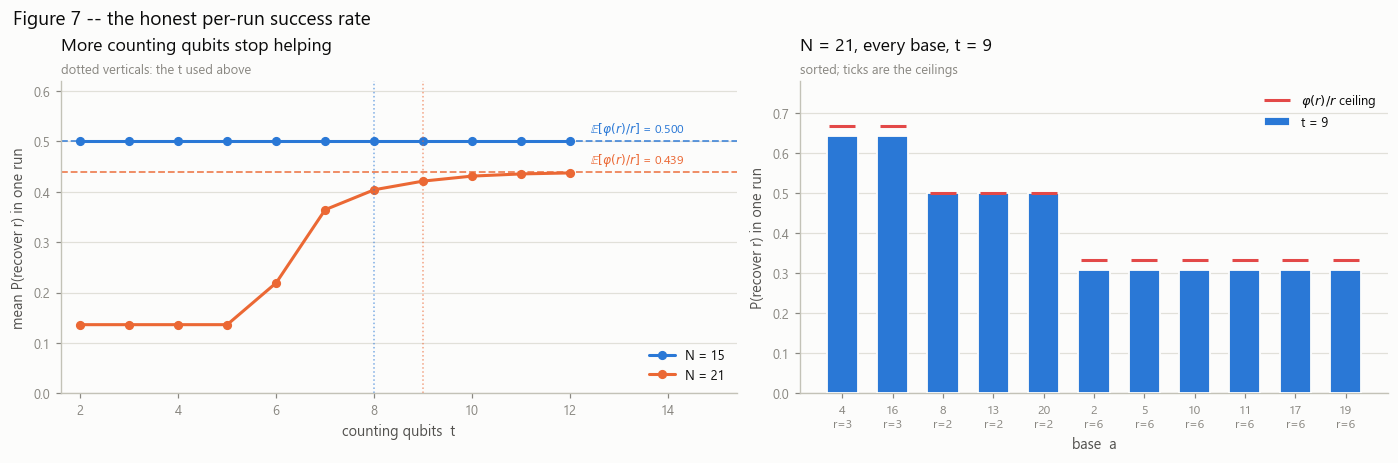

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.1),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
for N, c in [(15, style.BLUE), (21, style.ORANGE)]:
    cu = curves[N]
    ax.plot(cu["t"], cu["mean"], "-o", color=c, ms=5, label=f"N = {N}")
    ax.axhline(cu["ceiling"], color=c, ls="--", lw=1.2, alpha=0.8)
    ax.text(12.4, cu["ceiling"] + 0.008, r"$\mathbb{E}[\varphi(r)/r]$"
            + f" = {cu['ceiling']:.3f}", color=c, fontsize=8, va="bottom",
            ha="left")
for N, t, c in ((15, T15, style.BLUE), (21, T21, style.ORANGE)):
    ax.axvline(t, color=c, ls=":", lw=1.0, alpha=0.6)
ax.set_xlabel("counting qubits  t")
ax.set_ylabel("mean P(recover r) in one run")
ax.set_ylim(0, 0.62)
ax.set_xlim(1.6, 15.4)
ax.legend(loc="lower right", fontsize=8.5)
style.title(ax, "More counting qubits stop helping",
            "dotted verticals: the t used above")

ax = axes[1]
N = 21
ba = bases(N)
vals = [(a, qpe_success(a, N, T21), totient(order(a, N)) / order(a, N),
         order(a, N)) for a in ba]
vals.sort(key=lambda v: -v[1])
x = np.arange(len(vals))
ax.bar(x, [v[1] for v in vals], width=0.62, color=style.BLUE,
       edgecolor=style.SURFACE, lw=1.2, zorder=3, label=f"t = {T21}")
ax.plot(x, [v[2] for v in vals], ls="none", marker="_", ms=17, mew=2.0,
        color=style.RED, zorder=5, label=r"$\varphi(r)/r$ ceiling")
ax.set_xticks(x)
ax.set_xticklabels([f"{v[0]}\nr={v[3]}" for v in vals], fontsize=8)
ax.set_xlabel("base  a")
ax.set_ylabel("P(recover r) in one run")
ax.set_ylim(0, 0.78)
ax.legend(loc="upper right", fontsize=8.5)
style.title(ax, f"N = 21, every base, t = {T21}", "sorted; ticks are the ceilings")

fig.suptitle("Figure 7 -- the honest per-run success rate",
             fontsize=12.5, x=0.005, ha="left")
plt.show()

---

## Part 8 — an actual factorization, retries and all

Everything so far has been distributions. Here is the loop as you would really
run it: pick a random base, run the circuit, post-process, and if it fails, try
again. The lcm trick from Part 6 is in there — two runs whose denominators are
different divisors of $r$ often reconstruct $r$ between them.

The counter this prints is the honest cost: **how many circuit executions it took
to factor a two-digit number.**

In [16]:
def shor_once(N, a, t, rng):
    """One circuit execution: returns the integer m, sampled properly."""
    p = dirichlet_probs(order(a, N), t)
    return int(rng.choice(len(p), p=p / p.sum()))


def shor(N, t, rng, max_runs=40):
    """The full loop. Returns (factors, n_circuit_runs, log)."""
    log = []
    runs = 0
    while runs < max_runs:
        a = int(rng.choice(bases(N)))
        g = gcd(a, N)
        if g > 1:                                  # free lunch, never happens here
            return (g, N // g), runs, log
        cand = 1
        for _ in range(2):                         # the lcm-of-two-runs trick
            m = shor_once(N, a, t, rng)
            runs += 1
            d = recover_r(m, t, N)
            cand = cand * d // gcd(cand, d)
        r_hat = cand
        ok = pow(a, r_hat, N) == 1 and r_hat % 2 == 0
        fs = ()
        if ok:
            h = pow(a, r_hat // 2, N)
            fs = tuple(sorted({gcd(h - 1, N), gcd(h + 1, N)} - {1, N}))
        log.append((a, order(a, N), r_hat, fs))
        if fs:
            return fs, runs, log
    return (), runs, log


for N, t in ((15, T15), (21, T21)):
    r_rng = np.random.default_rng(SEED + N)
    fs, runs, log = shor(N, t, r_rng)
    print(f"--- N = {N}, t = {t} ---")
    for a, r_true, r_hat, got in log:
        verdict = f"FACTORS {got}" if got else "no factor, retry"
        print(f"    a = {a:>2}  true r = {r_true}  lcm of two runs -> r_hat = "
              f"{r_hat:>2}   {verdict}")
    print(f"    result: {N} = {' x '.join(map(str, fs))}   "
          f"after {runs} circuit executions\n")

trials = 300
for N, t in ((15, T15), (21, T21)):
    r_rng = np.random.default_rng(SEED + 1000 + N)
    costs = [shor(N, t, r_rng)[1] for _ in range(trials)]
    print(f"N = {N}: over {trials} full factorizations, circuit executions "
          f"needed -- median {int(np.median(costs))}, mean {np.mean(costs):.1f}, "
          f"90th pct {int(np.percentile(costs, 90))}, max {max(costs)}")

--- N = 15, t = 8 ---
    a =  4  true r = 2  lcm of two runs -> r_hat =  2   FACTORS (3, 5)
    result: 15 = 3 x 5   after 2 circuit executions

--- N = 21, t = 9 ---
    a = 17  true r = 6  lcm of two runs -> r_hat =  3   no factor, retry
    a = 10  true r = 6  lcm of two runs -> r_hat =  6   FACTORS (3, 7)
    result: 21 = 3 x 7   after 4 circuit executions



N = 15: over 300 full factorizations, circuit executions needed -- median 2, mean 3.3, 90th pct 6, max 12


N = 21: over 300 full factorizations, circuit executions needed -- median 4, mean 5.9, 90th pct 12, max 32


---

## Part 9 — honest limits: the oracle is a lie

Everything above is a correct simulation of Shor's algorithm. It is also, as an
argument that quantum computers can factor large numbers, worth nothing — and it
is important to be precise about why, because the failure is subtle and nearly
universal in runnable demos.

**The oracle was built by writing down the answer.** `cmul_gate` constructs the
full $2^n \times 2^n$ permutation matrix for $x \mapsto bx \bmod N$ and hands it
to the transpiler, which synthesizes gates for it. Two problems:

1. **It is exponentially large.** The matrix has $4^n$ entries in $n = \lceil\log_2
   N\rceil$ bits. For $N=21$ that is a $32\times32$ array. For RSA-2048 it is a
   $2^{2048} \times 2^{2048}$ array, and no amount of engineering makes that a
   thing you can build. A genuine Shor implementation constructs the multiplier
   from **reversible modular arithmetic** — adders, comparators, controlled
   swaps — in $O(n^2)$ to $O(n^3)$ gates, never touching the matrix.
2. **We used $r$ to build it.** Not directly — `pow(a, 2**j, N)` is honest
   classical exponentiation — but the *sizing* of the whole exercise, the choice
   of $t$, and the decision to skip oracles where $a^{2^j} \equiv 1$, all lean on
   knowing what the answer looks like. Smolin, Smith and Vargo made this point
   sharply in 2013 ("Oversimplifying quantum factoring", *Nature* 499): several
   published "experimental factorizations" had compiled so much knowledge of the
   answer into the circuit that a two-qubit device sufficed, and the same
   compilation would "factor" numbers of any size.

The reason to do it this way anyway is that the *interference* — Parts 3 through
7 — is completely faithful. The eigenvalue structure, the $\varphi(r)/r$ ceiling,
the leakage, the retry cost: all of that is exactly what a real machine would see.
It is only the resource count that is fantasy.

**The other things this notebook does not model:** no gate errors, no decoherence,
no measurement error, no connectivity constraints, no error correction. The
$N=21$ circuit transpiles to **9,120 CX gates at depth 17,811** (printed in Part
4) — on any current device the state would be thoroughly mixed several thousand
gates before the inverse QFT ran.
That is the actual reason nobody has factored 21 this way on real hardware without
compiling in the answer.

In [17]:
# What our oracle costs, and what it would cost.
print("The oracle as we built it -- a dense permutation matrix:")
print(f"{'N':>6} {'bits n':>7} {'matrix entries':>18} {'CX after transpile':>20}")
for N in (15, 21):
    nw = int(np.ceil(np.log2(N)))
    a = 7 if N == 15 else 2
    q = QuantumCircuit(nw + 1)
    q.append(cmul_gate(a, N, nw), range(nw + 1))
    tq = transpile(q, basis_gates=["u", "cx"], optimization_level=2,
                   seed_transpiler=SEED)
    print(f"{N:>6} {nw:>7} {4 ** (nw + 1):>18,} {tq.count_ops().get('cx', 0):>20}")

print("\nExtrapolated -- entries in the matrix we would have to write down.")
print("These are computed in log space: 4.0 ** 2049 overflows a float64, which")
print("is itself a reasonable summary of the problem.")
for n_bits in (8, 16, 24, 32, 64, 2048):
    e = (n_bits + 1) * np.log10(4.0)
    print(f"  n = {n_bits:>5} bits: {'10^%.1f' % e:>12} entries"
          f"   = {'10^%.1f' % (e + np.log10(16)):>12} bytes at complex128")
print("\nA real implementation never forms the matrix: reversible modular")
print("arithmetic gives the same unitary in O(n^2)-O(n^3) gates.")

The oracle as we built it -- a dense permutation matrix:
     N  bits n     matrix entries   CX after transpile
    15       4              1,024                  236
    21       5              4,096                 1004

Extrapolated -- entries in the matrix we would have to write down.
These are computed in log space: 4.0 ** 2049 overflows a float64, which
is itself a reasonable summary of the problem.
  n =     8 bits:       10^5.4 entries   =       10^6.6 bytes at complex128
  n =    16 bits:      10^10.2 entries   =      10^11.4 bytes at complex128
  n =    24 bits:      10^15.1 entries   =      10^16.3 bytes at complex128
  n =    32 bits:      10^19.9 entries   =      10^21.1 bytes at complex128
  n =    64 bits:      10^39.1 entries   =      10^40.3 bytes at complex128
  n =  2048 bits:    10^1233.6 entries   =    10^1234.8 bytes at complex128

A real implementation never forms the matrix: reversible modular
arithmetic gives the same unitary in O(n^2)-O(n^3) gates.


### Figure 8 — the wall

**Left:** qubit counts on a log scale. The two bars at the bottom are what we
actually ran. Above them, published estimates for RSA-2048: Beauregard's
$2n+3 = 4099$ **logical** qubits (2003), and Gidney & Ekerå's 20 million
**physical** qubits running for 8 hours (*Quantum* **5**, 433, 2021) once surface-code
overhead is included. The 2021 figure has since been pushed down — Gidney's 2025
estimate is under a million physical qubits over roughly a week — but the gap to a
14-qubit simulation is five to six orders of magnitude either way, and the honest
summary is that the number keeps moving and is still enormous.

**Right:** why our method specifically cannot be scaled. The blue curve is the
memory needed for the dense oracle matrix, $16 \cdot 4^{\,n+1}$ bytes. The orange
curve is a $\sim 50n^3$ gate count for reversible modular arithmetic, the way it
is actually done. They diverge immediately: the dense matrix passes a terabyte at
$n \approx 20$ bits and the observable universe's particle count around
$n \approx 130$, while the arithmetic circuit for RSA-2048 is a few times $10^{11}$
gates — enormous, entirely finite, and the reason the algorithm is a threat rather
than a curiosity.

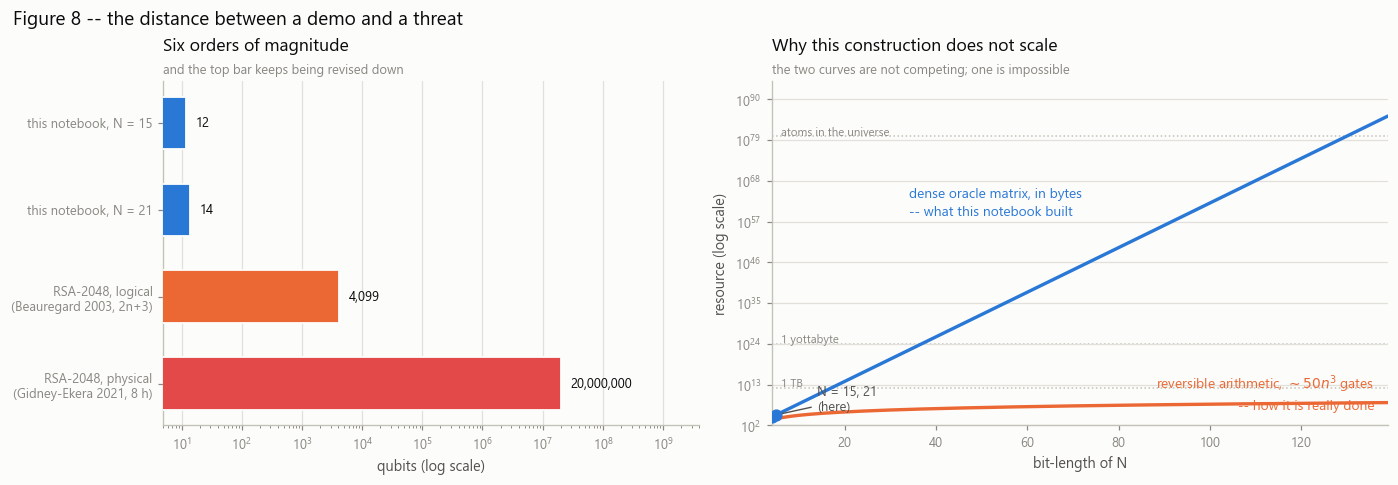

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3),
                         gridspec_kw={"width_ratios": [1, 1.15]})

ax = axes[0]
items = [
    ("this notebook, N = 15", T15 + 4, style.BLUE),
    ("this notebook, N = 21", T21 + 5, style.BLUE),
    ("RSA-2048, logical\n(Beauregard 2003, 2n+3)", 4099, style.ORANGE),
    ("RSA-2048, physical\n(Gidney-Ekera 2021, 8 h)", 20_000_000, style.RED),
]
y = np.arange(len(items))
ax.barh(y, [v for _, v, _ in items], color=[c for *_, c in items], height=0.6,
        edgecolor=style.SURFACE, lw=1.2, zorder=3)
for yy, (_, v, _) in zip(y, items):
    ax.text(v * 1.45, yy, f"{v:,}", va="center", fontsize=8.5, color=style.INK)
ax.set_yticks(y)
ax.set_yticklabels([l for l, *_ in items], fontsize=8.5)
ax.set_xscale("log")
ax.set_xlim(5, 4e9)
ax.invert_yaxis()
ax.set_xlabel("qubits (log scale)")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
style.title(ax, "Six orders of magnitude", "and the top bar keeps being revised down")

ax = axes[1]
nb = np.arange(4, 140)
dense_bytes = 16.0 * 4.0 ** (nb + 1)
arith_gates = 50.0 * nb ** 3.0
ax.semilogy(nb, dense_bytes, color=style.BLUE, lw=2.2)
ax.semilogy(nb, arith_gates, color=style.ORANGE, lw=2.2)
for val, lab in ((1e12, "1 TB"), (1e24, "1 yottabyte"),
                 (1e80, "atoms in the universe")):
    ax.axhline(val, color=style.AXIS, ls=":", lw=1.0, zorder=1)
    ax.text(6, val * 3.0, lab, fontsize=7.5, color=style.MUTED, ha="left")
ax.text(34, 1e62, "dense oracle matrix, in bytes\n-- what this notebook built",
        color=style.BLUE, fontsize=9, ha="left", va="center", linespacing=1.5)
ax.text(136, 8e10, r"reversible arithmetic, $\sim 50n^3$ gates"
        + "\n-- how it is really done", color=style.ORANGE, fontsize=9,
        ha="right", va="center", linespacing=1.5)
for n_mark, c in ((4, style.BLUE), (5, style.BLUE)):
    ax.plot([n_mark], [16.0 * 4.0 ** (n_mark + 1)], "o", ms=7, color=c, zorder=5)
grid.annotate(ax, "N = 15, 21\n(here)", (5, 16.0 * 4.0 ** 6), (14, 1e9))
ax.set_xlabel("bit-length of N")
ax.set_ylabel("resource (log scale)")
ax.set_ylim(1e2, 1e95)
ax.set_xlim(4, 139)
style.title(ax, "Why this construction does not scale",
            "the two curves are not competing; one is impossible")

fig.suptitle("Figure 8 -- the distance between a demo and a threat",
             fontsize=12.5, x=0.005, ha="left")
plt.show()

---

## Checkpoint

Track B notebooks close by asserting against the Track A result they mirror.
B24's partner is **A11** — the machinery is A11's phase estimation, applied to a
new operator — so the checkpoint rebuilds order-finding QPE **from scratch in
dense NumPy**, exactly the way A11 built QPE: explicit $2^{t+n}$ matrices,
`np.kron`, controlled permutations by index arithmetic, no Qiskit anywhere.

Three independent routes have to agree on the same distribution:

1. dense NumPy, first principles,
2. Qiskit's `Statevector` through the circuit from Part 4,
3. the closed-form Dirichlet sum.

Plus the algebra: the eigenvector identities, the $U^r = I$ property, the
$\varphi(r)/r$ ceiling as an exact limit of the $t$-sweep, and the endianness
convention that the whole thing rests on.

In [19]:
# ---- 0. A11-style from-scratch QPE. Dense matrices, np.kron, no Qiskit.
def dense_order_probs(a, N, t):
    """Order-finding QPE built the A11 way: explicit operators on 2**(t+nw)."""
    nw = int(np.ceil(np.log2(N)))
    D = 2 ** (t + nw)                             # index = m + 2**t * work

    H1 = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
    Hs = np.array([[1.0 + 0j]])
    for _ in range(t):
        Hs = np.kron(Hs, H1)                      # H^{ot t} on the counting bits
    layer_h = np.kron(np.eye(2 ** nw), Hs)        # work is the HIGH part

    psi = np.zeros(D, dtype=complex)
    psi[2 ** t * 1] = 1.0                         # |work = 1, count = 0>
    psi = layer_h @ psi

    for j in range(t):
        b = pow(a, 2 ** j, N)
        M = np.zeros((D, D))
        for idx in range(D):
            m, w = idx % 2 ** t, idx // 2 ** t
            w2 = ((b * w) % N if w < N else w) if (m >> j) & 1 else w
            M[m + 2 ** t * w2, idx] = 1.0
        psi = M @ psi

    jj = np.arange(2 ** t)
    F = np.exp(2j * np.pi * np.outer(jj, jj) / 2 ** t) / np.sqrt(2 ** t)
    psi = np.kron(np.eye(2 ** nw), F.conj().T) @ psi     # inverse QFT

    return (np.abs(psi) ** 2).reshape(2 ** nw, 2 ** t).sum(axis=0)


for a, t in ((7, 4), (2, 5), (4, 4)):
    d = dense_order_probs(a, 15, t)
    assert np.allclose(d, qiskit_probs(a, 15, t), atol=1e-10), (a, t)
    assert np.allclose(d, dirichlet_probs(order(a, 15), t), atol=1e-10), (a, t)
    assert np.isclose(d.sum(), 1.0)
d21 = dense_order_probs(2, 21, 4)
assert np.allclose(d21, qiskit_probs(2, 21, 4), atol=1e-10)
assert np.allclose(d21, dirichlet_probs(6, 4), atol=1e-10)

# ---- 1. Qiskit vs the closed form at the sizes actually plotted.
for N, a, t in CASES:
    p, q = qiskit_probs(a, N, t), dirichlet_probs(order(a, N), t)
    assert np.allclose(p, q, atol=1e-9), (N, a, t)
    assert np.isclose(p.sum(), 1.0, atol=1e-10)

# ---- 2. The oracle really is a permutation of order r, for every base.
for N in (15, 21):
    nw = int(np.ceil(np.log2(N)))
    I = np.eye(2 ** nw)
    for a in bases(N):
        P = perm_matrix(a, N, nw)
        assert np.array_equal(P, P.astype(bool).astype(float))     # 0/1 only
        assert np.allclose(P @ P.T, I)                             # unitary
        assert np.allclose(P.sum(axis=0), 1) and np.allclose(P.sum(axis=1), 1)
        r = order(a, N)
        assert np.allclose(np.linalg.matrix_power(P, r), I), (N, a)
        for k in range(1, r):
            assert not np.allclose(np.linalg.matrix_power(P, k), I)  # r minimal

# ---- 3. Eigenvectors: eigen-relation, orthonormality, telescoping sum.
for N in (15, 21):
    nw = int(np.ceil(np.log2(N)))
    for a in bases(N):
        r = order(a, N)
        P = perm_matrix(a, N, nw)
        us = [eigvec(s, a, N, nw) for s in range(r)]
        e1 = np.zeros(2 ** nw, dtype=complex)
        e1[1] = 1.0
        for s, u in enumerate(us):
            assert np.allclose(P @ u, np.exp(2j * np.pi * s / r) * u, atol=1e-12)
            assert np.isclose(np.linalg.norm(u), 1.0)
            assert np.isclose(abs(np.vdot(u, e1)) ** 2, 1 / r)      # uniform s
        assert np.allclose(sum(us) / np.sqrt(r), e1, atol=1e-12)    # = |1>
        G = np.array([[np.vdot(u, w) for w in us] for u in us])
        assert np.allclose(G, np.eye(r), atol=1e-12)

# ---- 4. THE endianness assertion: control on the LOW bit of the gate matrix.
#         The textbook block_diag(I, P) is the wrong object here, and this pins
#         which one Qiskit actually applies.
for N, a in ((15, 7), (21, 2)):
    nw = int(np.ceil(np.log2(N)))
    P = perm_matrix(a, N, nw)
    got = Operator(cmul_gate(a, N, nw)).data
    ctrl_low = np.zeros((2 ** (nw + 1),) * 2)
    for x in range(2 ** nw):
        ctrl_low[2 * x, 2 * x] = 1.0
        ctrl_low[2 * (P[:, x].argmax()) + 1, 2 * x + 1] = 1.0
    assert np.allclose(got, ctrl_low)
    assert not np.allclose(got, np.block([[np.eye(2 ** nw), 0 * P], [0 * P, P]]))
    # and it does what it says on a real circuit: |c=1, x=1> -> |c=1, a mod N>
    qc = QuantumCircuit(nw + 1)
    qc.x(0)                                        # control
    qc.x(1)                                        # work = 1
    qc.append(cmul_gate(a, N, nw), range(nw + 1))
    assert int(np.argmax(np.abs(Statevector(qc).data))) == 1 + 2 * (a % N)

# ---- 5. Classical reduction: the published hit rates, exactly.
assert sum(1 for *_, f in TABLE[15] if f) == 6 and len(TABLE[15]) == 7
assert sum(1 for *_, f in TABLE[21] if f) == 6 and len(TABLE[21]) == 11
for N in (15, 21):
    for a, r, _, f in TABLE[N]:
        assert pow(a, r, N) == 1 and all(pow(a, k, N) != 1 for k in range(1, r))
        if f:
            assert all(N % x == 0 and 1 < x < N for x in f)
            assert r % 2 == 0 and pow(a, r // 2, N) != N - 1

# ---- 6. Continued fractions recover r exactly when gcd(s, r) = 1, and the
#         t-sweep converges to the phi(r)/r ceiling from below.
for N in (15, 21):
    for a in bases(N):
        r = order(a, N)
        for s in range(r):
            m = int(round(s * 2 ** 12 / r))
            assert (recover_r(m, 12, N) == r) == (gcd(s, r) == 1), (N, a, s)
        seq = [qpe_success(a, N, t) for t in range(6, 14)]
        assert all(seq[i] <= seq[i + 1] + 1e-12 for i in range(len(seq) - 1))
        ceil_a = totient(r) / r
        assert seq[-1] <= ceil_a + 1e-12
        assert abs(seq[-1] - ceil_a) < 0.02          # converging to it
        if 2 ** 6 % r == 0:                          # exact case: pinned at once
            assert all(abs(v - ceil_a) < 1e-12 for v in seq)

assert np.isclose(curves[15]["ceiling"], 0.5)
assert all(abs(v - 0.5) < 1e-12 for v in curves[15]["mean"])   # flat, exactly

# ---- 7. The sampled run agrees with the exact distribution within shot noise.
assert abs(p_meas.sum() - 1.0) < 1e-12
for m in np.argsort(p_exact)[::-1][:4]:
    assert abs(p_meas[m] - p_exact[m]) <= 4 * max(sig[m], 1e-12), m
assert set(np.flatnonzero(p_exact > 1e-9)) == {0, 64, 128, 192}

# ---- 8. Order finding really does factor these numbers.
for N, t in ((15, T15), (21, T21)):
    fs, runs, _ = shor(N, t, np.random.default_rng(SEED + N))
    assert len(fs) >= 1 and all(N % f == 0 and 1 < f < N for f in fs)
    assert np.prod(sorted(fs)[:2]) == N or len(fs) == 1

print("B24 checkpoint passed.")
print("  dense NumPy == Qiskit == closed form, N = 15 and 21")
print(f"  classical reduction usable for   : 6/7 bases (N=15), "
      f"6/11 bases (N=21)")
print(f"  mean P(recover r) in one run     : "
      f"{curves[15]['mean'][-1]:.4f} (N=15, flat in t), "
      f"{curves[21]['mean'][-1]:.4f} (N=21, t=12)")
print(f"  ceiling E[phi(r)/r]              : "
      f"{curves[15]['ceiling']:.4f} / {curves[21]['ceiling']:.4f}")

B24 checkpoint passed.
  dense NumPy == Qiskit == closed form, N = 15 and 21
  classical reduction usable for   : 6/7 bases (N=15), 6/11 bases (N=21)
  mean P(recover r) in one run     : 0.5000 (N=15, flat in t), 0.4374 (N=21, t=12)
  ceiling E[phi(r)/r]              : 0.5000 / 0.4394


---

**Next:** [B25 — Teleportation and Superdense Coding](B25_Teleportation_Superdense.ipynb).
Back to small circuits, but with a new ingredient: mid-circuit measurement and
classical feed-forward, written with `with qc.if_test((creg, val))` — the
replacement for the removed `.c_if`. Fidelity over 20 random states, and what
"the state moved" does and does not mean.